In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 11 — Useful representations, Mapper, time windows, and honest machine learning

Read `lessons/11_lesson.md` first. Predict each result before execution. This is a fully worked lab; independent exercises and solutions are separate. All real examples before Stage 12 restrict digit displays to training data.

## Setup
This cell locates the project, loads standard numerical tools, and creates only this stage’s output folder. The mathematical work begins below.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "data/manifest.json").exists() and (p / "src/shape_lab").exists()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the extracted listening_to_shape_lab folder.")
sys.path.insert(0, str(ROOT / "src"))
from shape_lab.display import show_and_save, save_json
OUT = ROOT / "reports/stage_11"
OUT.mkdir(parents=True, exist_ok=True)
print("Output folder:", OUT.relative_to(ROOT))

Output folder: reports/stage_11


## One real diagram, several representations
Landscape and persistence-image coordinates describe a diagram, not the original image’s spatial coordinates.

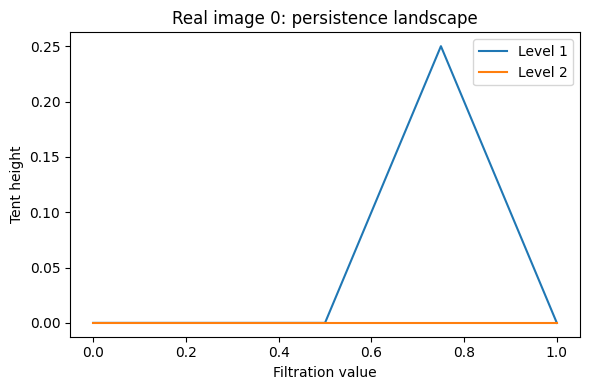

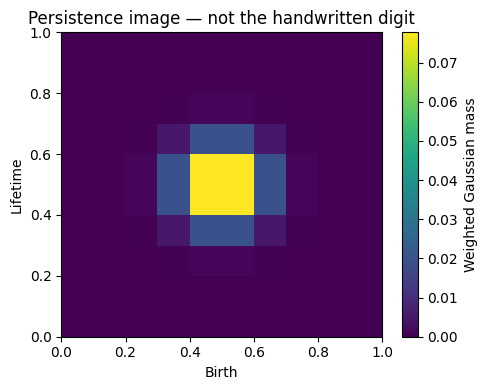

In [3]:
from shape_lab.data import digit_example, load_iris_data, load_digit_data
from shape_lab.persistence import pixel_filtration,persistent_homology,diagram
from shape_lab.features import persistence_landscape,persistence_image,delay_embedding,FEATURE_NAMES
image,sample_id=digit_example(0)
dgm=diagram(persistent_homology(pixel_filtration(1-image.astype(float)/16)),1,finite_only=True)
grid=np.linspace(0,1,101)
landscape=persistence_landscape(dgm,grid,levels=2)
plt.figure(figsize=(6,4))
for level in range(2): plt.plot(grid,landscape[level],label=f"Level {level+1}")
plt.legend();plt.xlabel("Filtration value");plt.ylabel("Tent height");plt.title(f"Real image {sample_id}: persistence landscape")
show_and_save(OUT / "landscape.png")
pi=persistence_image(dgm,np.linspace(0,1,11),np.linspace(0,1,11),sigma=.08)
plt.figure(figsize=(5,4));plt.imshow(pi,origin="lower",extent=[0,1,0,1],aspect="auto")
plt.colorbar(label="Weighted Gaussian mass");plt.xlabel("Birth");plt.ylabel("Lifetime")
plt.title("Persistence image — not the handwritten digit")
show_and_save(OUT / "persistence_image.png")

## Mapper on real Iris data
This is the graph of shared observations, not a guarantee of a true Reeb graph. The scalar lens and cover are declared.

Mapper sensitivity: [{'overlap': 0.2, 'nodes': 21, 'edges': 9}, {'overlap': 0.4, 'nodes': 23, 'edges': 11}]


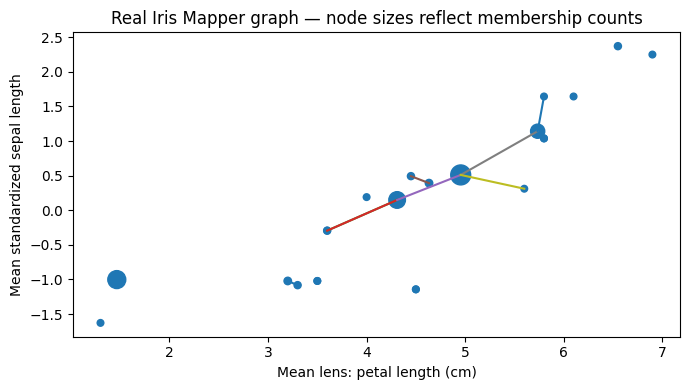

In [4]:
from shape_lab.mapper import mapper_graph
from sklearn.preprocessing import StandardScaler
iris=load_iris_data();X=iris.iloc[:,1:5].to_numpy()
Z=StandardScaler().fit_transform(X) # exploratory, not a predictive fit
lens=X[:,2] # petal length, not the label
mapper_results=[]
for overlap in [.2,.4]:
    graph=mapper_graph(Z,lens,n_intervals=5,overlap=overlap,eps=.6)
    mapper_results.append({"overlap":overlap,"nodes":len(graph["nodes"]),"edges":len(graph["edges"])})
print("Mapper sensitivity:",mapper_results)
graph=mapper_graph(Z,lens,n_intervals=5,overlap=.4,eps=.6)
plt.figure(figsize=(7,4))
for edge in graph["edges"]:
    a=graph["nodes"][edge["source"]]; b=graph["nodes"][edge["target"]]
    plt.plot([a["lens_mean"],b["lens_mean"]],[a["feature_mean"],b["feature_mean"]])
plt.scatter([n["lens_mean"] for n in graph["nodes"]],[n["feature_mean"] for n in graph["nodes"]],
            s=[20+3*len(n["members"]) for n in graph["nodes"]])
plt.xlabel("Mean lens: petal length (cm)");plt.ylabel("Mean standardized sepal length")
plt.title("Real Iris Mapper graph — node sizes reflect membership counts")
show_and_save(OUT / "mapper_graph.png")
save_json(OUT / "mapper_graph.json",graph)

## A time-window operation with honest labels
The sinusoid is synthetic. The digit column profile is real but spatial, not a recorded time series.

In [5]:
synthetic=np.sin(np.linspace(0,6*np.pi,80))
synthetic_windows=delay_embedding(synthetic,dimension=3,lag=3)
spatial_profile=image.sum(axis=0)
spatial_windows=delay_embedding(spatial_profile,dimension=3,lag=1)
print("Synthetic temporal windows:",synthetic_windows.shape)
print("Real image spatial windows:",spatial_windows)
assert np.array_equal(spatial_windows[0],spatial_profile[:3])

Synthetic temporal windows: (74, 3)
Real image spatial windows: [[ 0. 18. 84.]
 [18. 84. 48.]
 [84. 48. 40.]
 [48. 40. 68.]
 [40. 68. 36.]
 [68. 36.  0.]]


## Train and validation only: prespecified model comparison
Topological extraction is fixed and per-image. Scalers are fitted inside pipelines on training rows only. The test split is not loaded here.

In [6]:
from shape_lab.cache import feature_data,fingerprint
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
train_images,y_train,train_ids=load_digit_data("train")
val_images,y_val,val_ids=load_digit_data("validation")
T_train,_,_=feature_data("train"); T_val,_,_=feature_data("validation")
P_train=train_images.reshape(len(train_images),-1).astype(float)
P_val=val_images.reshape(len(val_images),-1).astype(float)
representations={"pixels":(P_train,P_val),"topology":(T_train,T_val),
                 "combined":(np.column_stack([P_train,T_train]),np.column_stack([P_val,T_val]))}
validation_rows=[];selected={}
for name,(X_train,X_val) in representations.items():
    candidates=[]
    for C_value in [.1,1.,10.]:
        model=make_pipeline(StandardScaler(),LogisticRegression(C=C_value,max_iter=3000))
        model.fit(X_train,y_train)
        score=float(accuracy_score(y_val,model.predict(X_val)))
        row={"representation":name,"C":C_value,"validation_accuracy":score}
        validation_rows.append(row);candidates.append(row)
    # Tie-break: prefer smaller C (stronger regularization), declared in advance.
    selected[name]=sorted(candidates,key=lambda r:(-r["validation_accuracy"],r["C"]))[0]["C"]
print(pd.DataFrame(validation_rows).to_string(index=False))
print("Selected C values:",selected)
selection={"fingerprint":fingerprint(),"selected_C":selected,"validation_results":validation_rows,
           "train_count":len(train_ids),"validation_count":len(val_ids),"test_used":False,
           "feature_names":FEATURE_NAMES,"split_limitation":"Per-image, not writer-disjoint."}
save_json(OUT / "validation_selection.json",selection)
save_json(OUT / "results.json",{"mapper_sensitivity":mapper_results,"validation":selection})

Computing fixed topology features for train: 1077 images.


Computing fixed topology features for validation: 360 images.


representation    C  validation_accuracy
        pixels  0.1             0.947222
        pixels  1.0             0.963889
        pixels 10.0             0.955556
      topology  0.1             0.430556
      topology  1.0             0.447222
      topology 10.0             0.430556
      combined  0.1             0.969444
      combined  1.0             0.966667
      combined 10.0             0.969444
Selected C values: {'pixels': 1.0, 'topology': 1.0, 'combined': 0.1}


## Stop before test-driven tuning
The saved selection is the handoff to Stage 12. Do not try new features because of test scores later. A negative topology result remains a valid outcome.

## Mastery gate
Build declared representations, explain Mapper and window availability, and select models using validation rather than test data.

A successful Run All is computational evidence, not a learner pass. Complete the lesson’s original exercises before reading `solutions/11_solutions.md`. Record independent work, corrections and a delayed re-test in your learner ledger.

## Sources and conventions
Source IDs: R2, R8, R9, D3; direct links and assignments are in `docs/SOURCES.md`. Core conventions are in `docs/MATHEMATICAL_CONVENTIONS.md`.